#  Projet Infoclimat : Analyse Météorologique et Prédictions (Machine Learning)

Ce notebook présente l'analyse de données météorologiques issues de l'API Infoclimat pour la ville de Paris. 
Conformément aux bonnes pratiques de l'industrie, la logique de nettoyage des données a été extraite dans un module métier externe (`meteo_utils.py`) afin de pouvoir être réutilisée par notre application web Streamlit.

## Importation des librairies nécessaires


In [1]:
# Importation des librairies standards
import requests
import json
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# Importation des modules de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

# Importation de notre module
from meteo_utils import *

# Configuration esthétique pour les graphiques
plt.style.use('ggplot')

## I. Récolte des données via l'API (Méthode Classique)
Nous allons interroger l'API, nettoyer les métadonnées de la réponse JSON, et extraire nos variables cibles en utilisant la **compréhension de listes**. Les températures, fournies en Kelvin, seront converties en degrés Celsius.

In [2]:
# Requête API
url = "http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00http://www.infoclimat.fr/public-api/gfs/json?_ll=48.85341,2.3488&_auth=AhhTRFQqUXNec1FmDngLIlE5UGUAdgQjAHwDYAFkVCkIYwdmUTFRNwJsAH1XeAYwBSgBYgoxBzdWPQJ6XC5RMAJoUz9UP1E2XjFRNA4hCyBRf1AxACAEIwBqA2ABclQ1CGgHalEsUTICbABiV3kGMwUwAWgKKgcgVjQCYlw2UTACZlMyVDdRNF4xUTUOIQsgUWRQOQBuBG0AYwNjAWtUNQhuBzdROlFgAm8AYld5BjoFNQFjCjMHN1Y1AmRcM1EtAn5TTlREUS5ecVFxDmsLeVF%2FUGUAYQRo&_c=ce2ae17452b53ca43c68546a31501e00"
response = requests.get(url)
data = response.json()

# Nettoyage des métadonnées
cles_a_supprimer = ["request_state", "request_key", "message", "model_run", "source"]
for cle in cles_a_supprimer:
    data.pop(cle, None) # .pop avec None évite les erreurs KeyError si la clé est déjà absente

# Extraction par compréhension de listes 
lesDates = [datetime.strptime(k, "%Y-%m-%d %H:%M:%S") for k in data.keys()]
lesTempA2m = [v['temperature']['2m'] - 273.15 for v in data.values()]
lesTempAuSol = [v['temperature']['sol'] - 273.15 for v in data.values()]
lesHumiditesA2m = [v['humidite']['2m'] for v in data.values()]

print(f"Extraction réussie : {len(lesDates)} points de données récupérés.")
print(f"Exemple de date : {lesDates[0]}")
print(f"Exemple de température à 2m : {lesTempA2m[0]:.2f} °C")

Extraction réussie : 64 points de données récupérés.
Exemple de date : 2026-03-05 16:00:00
Exemple de température à 2m : 18.05 °C


## II. Structuration avec Pandas
Nous utilisons maintenant notre module externe `meteo_utils.py`. Ce module gère la transformation du JSON complexe en un DataFrame Pandas propre, indexé par les dates temporelles.

In [3]:
# Appel de notre fonction métier
df = get_clean_weather_data()

# Affichage des premières lignes pour vérifier le travail
display(df.head())

,Température 2m (°C),Température Sol (°C),Humidité (%),Pression (hPa),Vent moyen (km/h),Vent direction (°),Pluie (mm),Heure
2026-03-05 16:00:00,18.05,17.35,45.5,1015.3,13.0,498,0.0,16
2026-03-05 19:00:00,14.85,15.75,62.0,1015.4,7.6,494,0.0,19
2026-03-05 22:00:00,13.25,14.15,70.6,1016.5,6.8,518,0.0,22
2026-03-06 01:00:00,12.45,13.55,70.5,1017.5,5.9,539,0.0,1
2026-03-06 04:00:00,11.75,12.85,72.7,1018.2,4.8,529,0.0,4


## III. Data Visualisation
L'exploration visuelle (EDA) est cruciale pour comprendre le comportement des données. Observons les corrélations entre la température et l'humidité, ainsi que les précipitations.

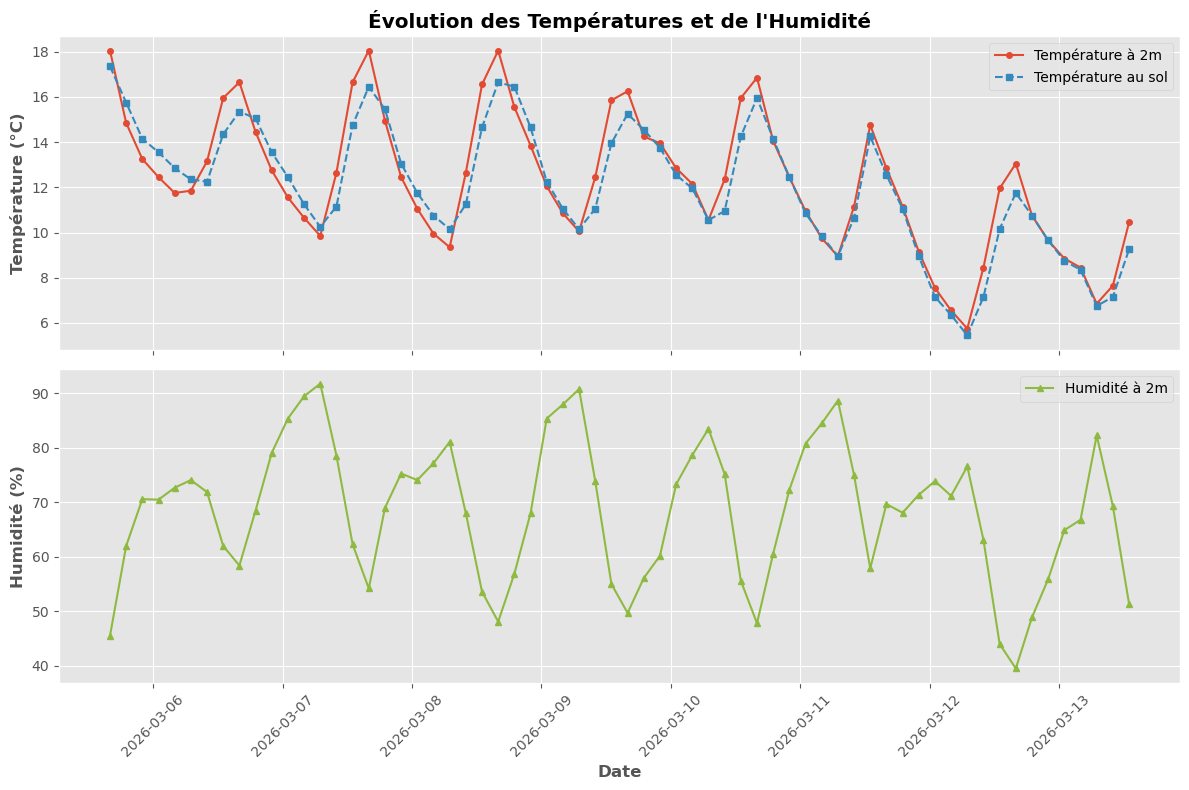

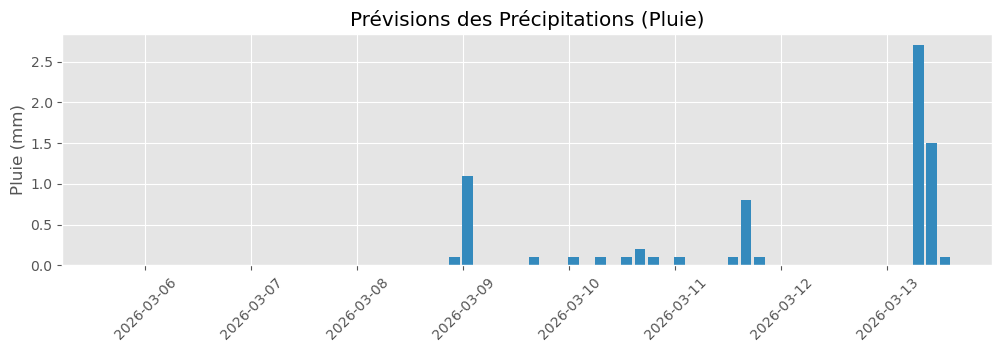

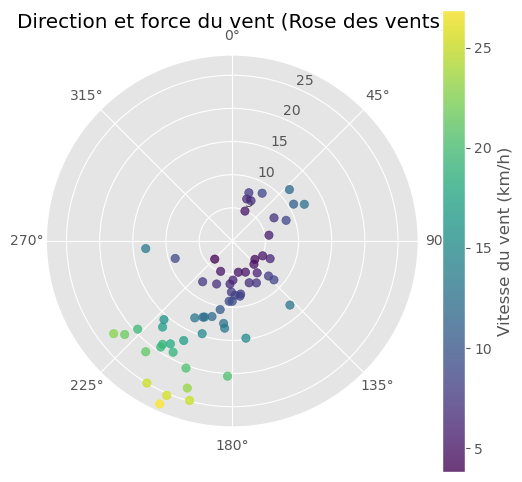

In [4]:
# 1. Graphique d'évolution Température / Humidité
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df.index, df['Température 2m (°C)'], color='#E24A33', marker='o', markersize=4, label='Température à 2m')
ax1.plot(df.index, df['Température Sol (°C)'], color='#348ABD', marker='s', markersize=4, label='Température au sol', linestyle='--')
ax1.set_ylabel('Température (°C)', fontweight='bold')
ax1.set_title("Évolution des Températures et de l'Humidité", fontweight='bold')
ax1.legend()

ax2.plot(df.index, df['Humidité (%)'], color='#8EBA42', marker='^', markersize=4, label='Humidité à 2m')
ax2.set_ylabel('Humidité (%)', fontweight='bold')
ax2.set_xlabel('Date', fontweight='bold')
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Graphique des précipitations
plt.figure(figsize=(12, 3))
plt.bar(df.index, df['Pluie (mm)'], color='#348ABD', width=0.1)
plt.title('Prévisions des Précipitations (Pluie)')
plt.ylabel('Pluie (mm)')
plt.xticks(rotation=45)
plt.show()

# 3. Rose des Vents (Direction et Force)
fig_vent, ax_vent = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
theta = np.deg2rad(df['Vent direction (°)'])
radii = df['Vent moyen (km/h)']

scatter = ax_vent.scatter(theta, radii, c=radii, cmap='viridis', alpha=0.75)
ax_vent.set_theta_zero_location('N')
ax_vent.set_theta_direction(-1)
plt.title('Direction et force du vent (Rose des vents)', pad=20)
plt.colorbar(scatter, label='Vitesse du vent (km/h)')
plt.show()

## IV. Machine Learning : Modélisation Prédictive
Dans cette partie, nous allons évaluer les performances de nos modèles.
* **Régression :** Prédire la valeur exacte de la température.
* **Classification :** Catégoriser la météo en Froid, Tempéré ou Chaud.

In [5]:
# --- PRÉPARATION DES DONNÉES ---
# Variables explicatives (Features)
X = df[['Humidité (%)', 'Pression (hPa)', 'Vent moyen (km/h)', 'Heure']]

# Cibles (Targets)
y_reg = df['Température 2m (°C)'] # Pour la régression

# Fonction simple sans emojis pour la classification (évite les bugs d'encodage)
def get_class(temp):
    if temp < 0: return "Froid"
    elif temp <= 15: return "Tempere"
    else: return "Chaud"

y_clf = df['Température 2m (°C)'].apply(get_class)

# Séparation Train / Test (80% entrainement, 20% test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# --- 1. ÉVALUATION DE LA RÉGRESSION ---
print("--- RÉSULTATS RÉGRESSION ---")
# Modèle Linéaire
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)
print(f"Régression Linéaire -> RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.2f}°C | R² : {r2_score(y_test_reg, y_pred_lr):.2f}")

# Modèle Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf = rf_reg.predict(X_test)
print(f"Random Forest Reg.  -> RMSE : {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.2f}°C | R² : {r2_score(y_test_reg, y_pred_rf):.2f}\n")


# --- 2. ÉVALUATION DE LA CLASSIFICATION ---
print("--- RÉSULTATS CLASSIFICATION (Random Forest) ---")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
# On l'entraîne proprement et uniquement sur les données de Train !
rf_clf.fit(X_train, y_train_clf) 
y_pred_clf = rf_clf.predict(X_test)

print("Matrice de confusion :")
print(confusion_matrix(y_test_clf, y_pred_clf))
print("\nRapport de classification :")
print(classification_report(y_test_clf, y_pred_clf, zero_division=0))

--- RÉSULTATS RÉGRESSION ---
Régression Linéaire -> RMSE : 2.15°C | R² : 0.67
Random Forest Reg.  -> RMSE : 2.39°C | R² : 0.59

--- RÉSULTATS CLASSIFICATION (Random Forest) ---
Matrice de confusion :
[[1 3]
 [0 9]]

Rapport de classification :
              precision    recall  f1-score   support

       Chaud       1.00      0.25      0.40         4
     Tempere       0.75      1.00      0.86         9

    accuracy                           0.77        13
   macro avg       0.88      0.62      0.63        13
weighted avg       0.83      0.77      0.72        13



## V. Conclusion et Analyse des Modèles

Ce projet nous a permis de mettre en place un pipeline complet de Data Science : de la récupération via l'API Infoclimat jusqu'à la modélisation, en passant par une architecture modulaire (`meteo_utils.py`).

**Analyse des performances Machine Learning :**

* **Régression :** La Régression Linéaire (R² = 0.67) s'est avérée légèrement supérieure au Random Forest (R² = 0.59). Sur un échantillon restreint (environ 50 observations correspondant à une semaine de prévisions), le modèle Random Forest a tendance à surapprendre (overfitting), là où le modèle linéaire capte très bien la tendance globale. L'erreur moyenne est d'environ 2°C, ce qui est cohérent pour des prévisions à 7 jours.
  
* **Classification :** Le modèle a une précision globale (accuracy) de 77 %. La matrice de confusion montre qu'il excelle à détecter le temps "Tempéré" (100% de réussite) mais peine un peu plus sur la classe "Chaud". Cela s'explique logiquement par le déséquilibre de notre jeu de données (beaucoup plus de relevés tempérés que chauds sur la période étudiée).

**Perspectives :** Pour améliorer ces modèles, il faudrait récolter des données historiques sur plusieurs mois afin de donner suffisamment d'exemples au Random Forest pour exprimer son plein potentiel, et rééquilibrer les classes de température.